# DATA586 Plot Notebook

Rubric-aligned order:
1. Baseline vs Custom model grouping
2. Clean test performance
3. Robustness on transformed test variants
4. Aggregate robustness
5. Performance vs Efficiency trade-off
6. Failure analysis (Confusion Matrix + Grad-CAM)


In [1]:
from pathlib import Path
import pandas as pd

from workflow import (
    get_latest_workflow_runs,
    build_split_analysis_from_latest,
    show_model_epoch_dynamics_paginated_interactive,
    plot_val_accuracy_all_models_interactive,
    plot_final_test_accuracy_model_comparison_interactive,
    plot_test_split_comparison_interactive,
    plot_efficiency_compare_interactive,
    show_model_confusions_paginated_interactive,
    show_gradcam_compare_all_models,
    show_workflow_summary_table,
    print_rubric_summary,
)

PROJECT_ROOT = Path.cwd()


## Runtime Safety (recommended)
Use CPU-first and keep heavy visualization off unless needed.


In [2]:
# Safety toggles
SAFE_DEVICE = 'cpu'
RUN_HEAVY_VIS = False  # turn True only when needed

print(f'SAFE_DEVICE={SAFE_DEVICE}, RUN_HEAVY_VIS={RUN_HEAVY_VIS}')


SAFE_DEVICE=cpu, RUN_HEAVY_VIS=False


## Step 1) Import all training logs (workflow)


In [3]:
runs_df, latest_df = get_latest_workflow_runs()
latest_df[[
    "generated_at_utc", "model_name", "model_type", "best_eval_acc", "final_test_acc", "clean_accuracy", "robustness_average", "path"
]]


Total workflow runs: 10
Latest unique models: 10


,generated_at_utc,model_name,model_type,best_eval_acc,final_test_acc,clean_accuracy,robustness_average,path
0,2026-04-07T16:54:49+00:00,efficientnet_full_finetune,Custom,0.741122,0.782772,0.782574,0.539976,C:\Users\18447\DATA586Project\logs\workflow_ru...
1,2026-04-07T13:53:03+00:00,resnet18_full_finetune,Custom,0.578218,0.606812,0.622812,0.423366,C:\Users\18447\DATA586Project\logs\workflow_ru...
2,2026-04-07T12:41:59+00:00,efficientnet_bn_tuning,Custom,0.793663,0.841386,0.838614,0.685933,C:\Users\18447\DATA586Project\logs\workflow_ru...
3,2026-04-07T10:22:12+00:00,resnet18_bn_tuning,Custom,0.631419,0.677188,0.672634,0.493766,C:\Users\18447\DATA586Project\logs\workflow_ru...
4,2026-04-07T09:21:01+00:00,efficientnet_tsa,Custom,0.693729,0.732634,0.730099,0.565141,C:\Users\18447\DATA586Project\logs\workflow_ru...
5,2026-04-07T05:17:13+00:00,resnet18_tsa,Custom,0.640528,0.661426,0.686574,0.531469,C:\Users\18447\DATA586Project\logs\workflow_ru...
6,2026-04-07T04:12:06+00:00,efficientnet_lora,Custom,0.645149,0.658931,0.687802,0.535778,C:\Users\18447\DATA586Project\logs\workflow_ru...
7,2026-04-07T02:16:33+00:00,resnet18_lora,Custom,0.501518,0.534337,0.533347,0.398440,C:\Users\18447\DATA586Project\logs\workflow_ru...
8,2026-04-07T01:17:06+00:00,efficientnet_baseline,Baseline (linear probe),0.483168,0.515327,0.521584,0.363651,C:\Users\18447\DATA586Project\logs\workflow_ru...
9,2026-04-06T23:55:38+00:00,resnet18_baseline,Baseline (linear probe),0.512079,0.549069,0.544911,0.378257,C:\Users\18447\DATA586Project\logs\workflow_ru...


## Step 2) Baseline vs Custom summary table


In [4]:
_ = show_workflow_summary_table(latest_df["path"].tolist())


,Model,Best Eval,Final Test,Clean,Robustness Avg,Trainable Params
0,efficientnet_full_finetune,0.7411,0.7828,0.7826,0.5400,"20,306,869"
1,resnet18_full_finetune,0.5782,0.6068,0.6228,0.4234,"11,228,325"
2,efficientnet_bn_tuning,0.7937,0.8414,0.8386,0.6859,"283,253"
3,resnet18_bn_tuning,0.6314,0.6772,0.6726,0.4938,"61,413"
4,efficientnet_tsa,0.6937,0.7326,0.7301,0.5651,"994,149"
5,resnet18_tsa,0.6405,0.6614,0.6866,0.5315,"379,493"
6,efficientnet_lora,0.6451,0.6589,0.6878,0.5358,"594,152"
7,resnet18_lora,0.5015,0.5343,0.5333,0.3984,"23,336"
8,efficientnet_baseline,0.4832,0.5153,0.5216,0.3637,"129,381"
9,resnet18_baseline,0.5121,0.5491,0.5449,0.3783,"51,813"


## Step 3) Clean test performance / Robustness per variant / Aggregate robustness


In [5]:
analysis = build_split_analysis_from_latest(latest_df, show_tables=True)
test_split_json_paths = analysis["test_split_json_paths"]
split_df = analysis["split_df"]
clean_and_agg_df = analysis["clean_and_agg_df"]
variant_df = analysis["variant_df"]


Model Summary + Robustness by Variant


,model_name,model_type,clean_accuracy,robustness_average,total_seconds,split::blur_little,split::blur_medium,split::clean,split::downsampled,split::masked,split::noise_rotation
2,efficientnet_bn_tuning,Custom,0.838614,0.685933,873.228949,0.786931,0.643921,0.838614,0.366693,0.829069,0.803050
0,efficientnet_full_finetune,Custom,0.782574,0.539976,1018.527231,0.680000,0.379366,0.782574,0.177109,0.756436,0.706970
4,efficientnet_tsa,Custom,0.730099,0.565141,927.371165,0.653307,0.490139,0.730099,0.278733,0.713663,0.689861
6,efficientnet_lora,Custom,0.687802,0.535778,1036.566932,0.614535,0.472871,0.687802,0.273545,0.671564,0.646376
5,resnet18_tsa,Custom,0.686574,0.531469,1001.388090,0.621069,0.480594,0.686574,0.307248,0.632475,0.615960
3,resnet18_bn_tuning,Custom,0.672634,0.493766,857.312682,0.595604,0.409228,0.672634,0.241109,0.621861,0.601030
1,resnet18_full_finetune,Custom,0.622812,0.423366,797.185353,0.518970,0.281901,0.622812,0.164238,0.587050,0.564673
9,resnet18_baseline,Baseline (linear probe),0.544911,0.378257,911.239619,0.459802,0.327564,0.544911,0.168950,0.466139,0.468832
7,resnet18_lora,Custom,0.533347,0.398440,957.462523,0.470931,0.345069,0.533347,0.217703,0.486891,0.471604
8,efficientnet_baseline,Baseline (linear probe),0.521584,0.363651,1004.271070,0.411604,0.274099,0.521584,0.146535,0.501267,0.484752


## Step 3.5) Epoch Dynamics + Final Test Comparison


In [6]:
training_log_paths = [p for p in latest_df["training_run_log"].dropna().tolist() if Path(str(p)).exists()]
_ = show_model_epoch_dynamics_paginated_interactive(training_log_paths, max_epochs=20, page_size=1)
_ = plot_val_accuracy_all_models_interactive(training_log_paths, max_epochs=20)
_ = plot_final_test_accuracy_model_comparison_interactive(training_log_paths)


## Step 4) Visualization: test variant comparison (workflow)


In [7]:
_ = plot_test_split_comparison_interactive(test_split_json_paths)


## Step 5) Visualization: performance-efficiency trade-offs (workflow)


In [8]:
training_log_paths = [p for p in latest_df["training_run_log"].dropna().tolist() if Path(str(p)).exists()]
_ = plot_efficiency_compare_interactive(training_log_paths)


## Step 6) Failure analysis: confusion matrix (workflow)


In [9]:
show_model_confusions_paginated_interactive(latest_df, top_k=10, page_size=1)


## Step 7) Failure analysis: Grad-CAM compare (workflow)


Running Grad-CAM compare on 10 models



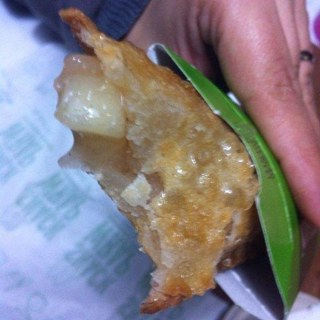
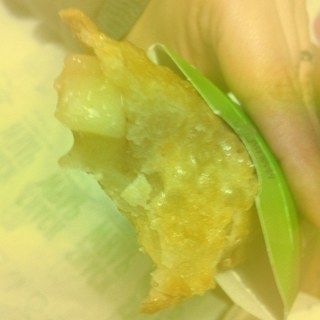
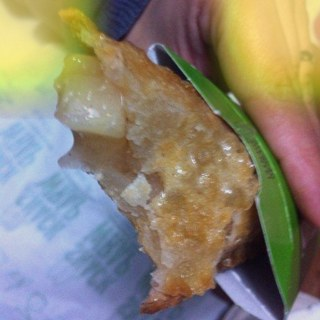
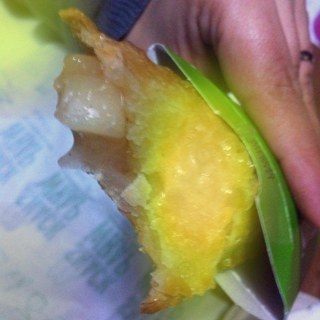
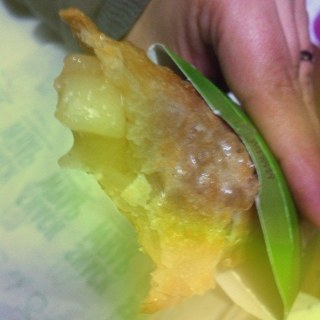
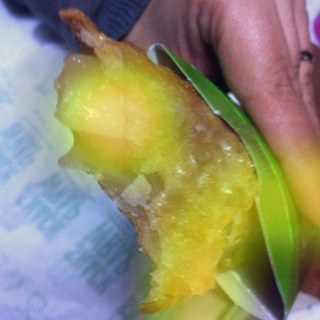
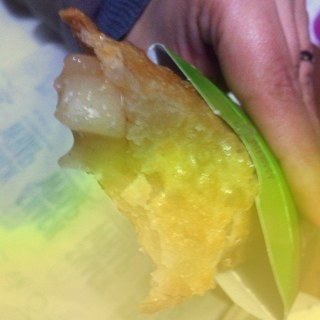
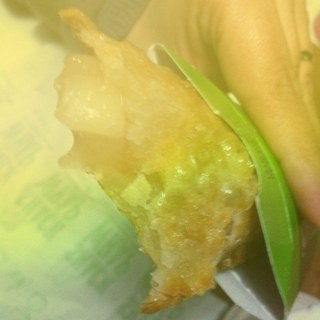
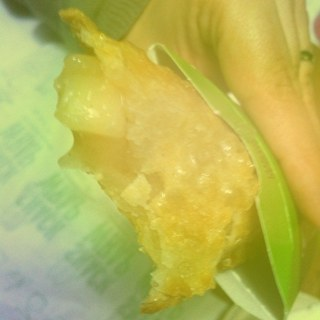
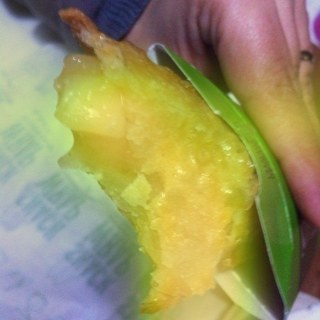
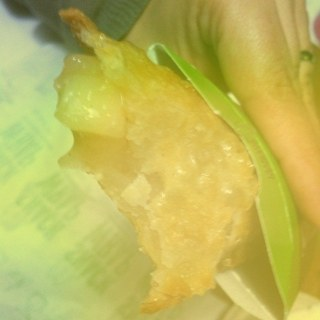

In [10]:
# Step 7: Grad-CAM compare (all models)
SAMPLE_IMAGE_PATH = r"C:\Users\18447\DATA586Project\data\test_splits\clean\apple_pie\1011328.jpg"  # keep your image path here
show_gradcam_compare_all_models(SAMPLE_IMAGE_PATH, image_size=128, device="cpu")


## Step 8) Auto-generated report text (ordered as rubric)


In [11]:
print_rubric_summary(clean_and_agg_df, variant_df)


[1] Performance on clean test set
- Baseline best: resnet18_baseline | clean_accuracy=0.5449
- Custom best:   efficientnet_bn_tuning | clean_accuracy=0.8386

[2] Robustness scores on each test set variant


,model_name,model_type,split::blur_little,split::blur_medium,split::clean,split::downsampled,split::masked,split::noise_rotation
8,efficientnet_baseline,Baseline (linear probe),0.411604,0.274099,0.521584,0.146535,0.501267,0.484752
2,efficientnet_bn_tuning,Custom,0.786931,0.643921,0.838614,0.366693,0.829069,0.803050
0,efficientnet_full_finetune,Custom,0.680000,0.379366,0.782574,0.177109,0.756436,0.706970
6,efficientnet_lora,Custom,0.614535,0.472871,0.687802,0.273545,0.671564,0.646376
4,efficientnet_tsa,Custom,0.653307,0.490139,0.730099,0.278733,0.713663,0.689861
9,resnet18_baseline,Baseline (linear probe),0.459802,0.327564,0.544911,0.168950,0.466139,0.468832
3,resnet18_bn_tuning,Custom,0.595604,0.409228,0.672634,0.241109,0.621861,0.601030
1,resnet18_full_finetune,Custom,0.518970,0.281901,0.622812,0.164238,0.587050,0.564673
7,resnet18_lora,Custom,0.470931,0.345069,0.533347,0.217703,0.486891,0.471604
5,resnet18_tsa,Custom,0.621069,0.480594,0.686574,0.307248,0.632475,0.615960



[3] Aggregate robustness


,model_name,model_type,robustness_average
2,efficientnet_bn_tuning,Custom,0.685933
4,efficientnet_tsa,Custom,0.565141
0,efficientnet_full_finetune,Custom,0.539976
6,efficientnet_lora,Custom,0.535778
5,resnet18_tsa,Custom,0.531469
3,resnet18_bn_tuning,Custom,0.493766
1,resnet18_full_finetune,Custom,0.423366
7,resnet18_lora,Custom,0.398440
9,resnet18_baseline,Baseline (linear probe),0.378257
8,efficientnet_baseline,Baseline (linear probe),0.363651



[4] Trade-off plots
- See Step 5: performance vs wall time / trainable params / inference speed

[5] Failure interpretation checklist
- Use Step 6 confusion matrices to identify dominant confusions
- Use Step 7 Grad-CAM to compare attention regions across model types
- Explain which transformed variants cause the largest accuracy drops
